# LASSO — SDY569 (single institution)

**Per-study notebook in the federated architecture.**

This notebook fits a LASSO (L1-regularised) regression on **SDY569 alone**
to predict log(C-peptide AUC). It is one "institution" in the federated
simulation: it never sees another study's subject-level data. Its outputs
that leave this notebook are a **coefficient vector** and the list of
**features it selected** (the non-zero coefficients), saved as CSV. A separate
federated notebook combines the studies' vectors with median+IQR and ADMM
consensus.

- **Input:** SDY569's Panel A and Panel B feature matrices.
- **Output:** `vectors/SDY569_lasso_panelA_vector.csv` and `vectors/SDY569_lasso_panelB_vector.csv`.


## Why LASSO

LASSO is linear regression with an **L1 penalty**. Unlike Ridge (which shrinks
every weight toward zero but keeps them all), LASSO drives some weights exactly
**to zero** — it performs *feature selection*. The features that survive with a
non-zero coefficient are the ones this institution found useful; everything
else is dropped.

This matters for the federated story: each institution selects features
locally, and the coordinator can then keep the features that are selected
consistently across institutions.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

import oadr_data as od

RNG_SEED = 42
np.random.seed(RNG_SEED)
(REPO / "vectors").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


## 2. Load SDY569 only

Same panels as the Ridge notebooks. Panel A (9 features) and Panel B (12 features; race/ethnicity excluded because their categories do not align across studies for aggregation).


In [2]:
PANEL_A_FEATS = ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
a = od.load_panel_a("SDY569")
Xa = a[PANEL_A_FEATS].values.astype(float)
ya = a[od.PANEL_A_TARGET].values.astype(float)
print(f"Panel A: N={len(ya)}, features={len(PANEL_A_FEATS)}")

PANEL_B_FEATS = ['Sex', 'age_years', 'disease_duration_years', 'bmi', 'height_cm', 'weight_kg', 'GAD65', 'IA2IC', 'MIAA', 'ZNT8', 'ICA', 'received_active_treatment']
b_raw = od.load_panel_b("SDY569")
for col in ("bmi", "height_cm", "weight_kg"):
    b_raw[col] = b_raw[col].fillna(b_raw[col].median())
bad_h = b_raw["height_cm"] <= 0
b_raw.loc[bad_h, "height_cm"] = np.sqrt(b_raw.loc[bad_h, "weight_kg"] / b_raw.loc[bad_h, "bmi"]) * 100
Xb_full, yb, _ = od.panel_b_design_matrix(b_raw)
Xb = Xb_full.reindex(columns=PANEL_B_FEATS).values.astype(float)
yb = yb.values.astype(float)
print(f"Panel B: N={len(yb)}, features={len(PANEL_B_FEATS)}")


Panel A: N=10, features=9
Panel B: N=10, features=12


## 3. MinMaxScaler — within-study harmonization

Autoantibody assays are on very different scales across studies (e.g. GAD65 is
0–1155 IU/ml in SDY569-scale studies but recorded 0/1 in others). **Within
SDY569 only**, each feature is min–max scaled to [0, 1]. This is the
preprocessing step every institution applies to its own data before any
coefficient is shared — exactly as a real federated protocol requires. Binary
indicators (Sex, treatment, age-group dummies) are already 0/1 and are
unchanged.


In [3]:
sc_a = MinMaxScaler().fit(Xa)
Xa_s = sc_a.transform(Xa)
if Xb is not None:
    sc_b = MinMaxScaler().fit(Xb)
    Xb_s = sc_b.transform(Xb)
else:
    Xb_s = None
print("Scaled Panel A shape:", Xa_s.shape)


Scaled Panel A shape: (10, 9)


## 4. Fit LassoCV locally and write the SDY569 vector

`LassoCV` picks the L1 penalty α by cross-validation **within SDY569**, then
fits the sparse model. The coefficient vector — with the selected α, the
sample size, and a `selected` flag (non-zero) per feature — is written to
`vectors/`. The `selected` flag is what the federated notebook uses for
consensus feature selection.


In [4]:
def fit_and_save(X_s, y, feats, panel_label):
    cv = max(2, min(5, len(y) // 4))
    m = LassoCV(cv=cv, random_state=RNG_SEED, max_iter=50000).fit(X_s, y)
    rows = [{"feature": "__intercept__", "coefficient": float(m.intercept_), "selected": 0}]
    rows += [{"feature": f, "coefficient": float(c), "selected": int(abs(c) > 1e-8)}
             for f, c in zip(feats, m.coef_)]
    vec = pd.DataFrame(rows)
    vec["n_subjects"] = len(y)
    vec["study"] = "SDY569"
    vec["panel"] = panel_label
    vec["alpha"] = float(m.alpha_)
    path = f"vectors/{"SDY569"}_lasso_panel{panel_label}_vector.csv"
    vec.to_csv(path, index=False)
    kept = [f for f, c in zip(feats, m.coef_) if abs(c) > 1e-8]
    print(f"Wrote {path}  (alpha={m.alpha_:.4f}, selected {len(kept)}/{len(feats)}: {kept})")
    return vec


In [5]:
vec_a = fit_and_save(Xa_s, ya, PANEL_A_FEATS, "A")
print()
print("Panel A coefficient vector:")
print(vec_a[["feature", "coefficient", "selected"]].to_string(index=False))

vec_b = fit_and_save(Xb_s, yb, PANEL_B_FEATS, "B")
print()
print("Panel B coefficient vector:")
print(vec_b[["feature", "coefficient", "selected"]].to_string(index=False))


Wrote vectors/SDY569_lasso_panelA_vector.csv  (alpha=0.0657, selected 1/9: ['8-12'])

Panel A coefficient vector:
      feature  coefficient  selected
__intercept__    -0.151530         0
         MIAA     0.000000         0
        GAD65    -0.000000         0
        IA2IC     0.000000         0
          ICA     0.000000         0
         ZNT8     0.000000         0
         8-12    -0.687459         1
        13-17     0.000000         0
          >18     0.000000         0
          Sex    -0.000000         0
Wrote vectors/SDY569_lasso_panelB_vector.csv  (alpha=0.0641, selected 3/12: ['bmi', 'weight_kg', 'received_active_treatment'])

Panel B coefficient vector:
                  feature  coefficient  selected
            __intercept__    -1.010973         0
                      Sex    -0.000000         0
                age_years     0.000000         0
   disease_duration_years     0.000000         0
                      bmi     0.256052         1
                height_cm    

## 5. SDY569 coefficient graphic

LASSO coefficients as a horizontal bar chart — green positive, red negative,
**grey at zero (dropped by LASSO)**. Panel A (left) and Panel B (right). The dropped features are
the ones SDY569 did not need; the coloured bars are what it selected.


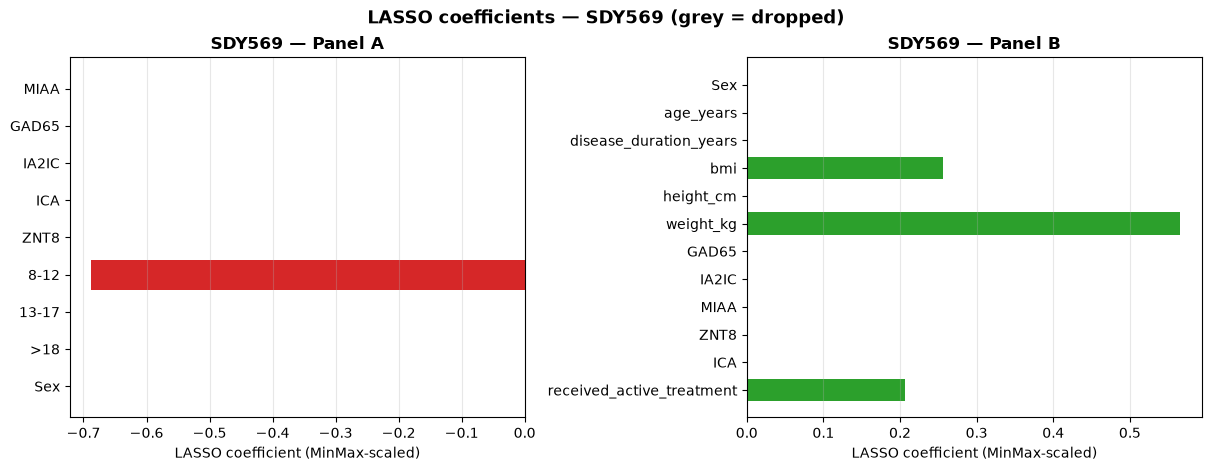

In [6]:
def plot_coef(ax, vec, title):
    d = vec[vec.feature != "__intercept__"]
    colors = ["#cccccc" if abs(c) <= 1e-8 else ("#2ca02c" if c > 0 else "#d62728")
              for c in d.coefficient]
    ax.barh(d.feature, d.coefficient, color=colors)
    ax.axvline(0, color="k", lw=0.6)
    ax.invert_yaxis()
    ax.set_xlabel("LASSO coefficient (MinMax-scaled)")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

panels = ["A", "B"]
vecs = {"A": vec_a, "B": vec_b}
fig, axes = plt.subplots(1, len(panels), figsize=(6.0 * len(panels), 4.6),
                         constrained_layout=True, squeeze=False)
for ax, p in zip(axes[0], panels):
    plot_coef(ax, vecs[p], f"SDY569 — Panel {p}")
fig.suptitle("LASSO coefficients — SDY569 (grey = dropped)",
             fontsize=13, fontweight="bold")
fig.savefig("figures/lasso_coef_SDY569.pdf", dpi=300)
fig.savefig("figures/lasso_coef_SDY569.png", dpi=220)
plt.show()


## 6. Solo performance (within-study cross-validation)

What SDY569 achieves **on its own**. 5-fold CV within SDY569 (fewer folds if
N is small); the MinMax scaler and LassoCV are fit on each training fold and
applied to the held-out fold. This is the baseline the federated model will be
compared against.


In [7]:
def solo_cv(X, y, n_splits=5, seed=RNG_SEED):
    n_splits = max(2, min(n_splits, len(y) // 2))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds = np.full_like(y, np.nan, dtype=float)
    for tr, te in kf.split(X):
        sc = MinMaxScaler().fit(X[tr])
        cv = max(2, min(3, len(tr) // 4))
        m = LassoCV(cv=cv, random_state=seed, max_iter=50000).fit(sc.transform(X[tr]), y[tr])
        preds[te] = m.predict(sc.transform(X[te]))
    mask = ~np.isnan(preds)
    mse = mean_squared_error(y[mask], preds[mask])
    rss = np.sum((y[mask] - preds[mask]) ** 2)
    tss = np.sum((y[mask] - y[mask].mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else float("nan")
    return mse, r2, n_splits

mse_a, r2_a, k_a = solo_cv(Xa, ya)
print(f"Panel A solo {k_a}-fold CV:  MSE={mse_a:.3f}  R²={r2_a:+.3f}")
if Xb is not None:
    mse_b, r2_b, k_b = solo_cv(Xb, yb)
    print(f"Panel B solo {k_b}-fold CV:  MSE={mse_b:.3f}  R²={r2_b:+.3f}")


Panel A solo 5-fold CV:  MSE=0.457  R²=-0.093
Panel B solo 5-fold CV:  MSE=0.574  R²=-0.372


## 7. Stage-1 artifact — LASSO model on the selected features

The federated LASSO determined four features on the extended panel (excluding
SDY1737): **weight_kg, GAD65, received_active_treatment, Sex**. SDY569 now fits
LASSO on those four features (its own data) and writes the coefficient vector to
`vectors/SDY569_lasso_sel_vector.csv`. The Stage-2 notebook
`LASSO_SDY569_federated_w_SDY_coefficients.ipynb` reads these vectors from every
institution, federates them, and produces the presentation graphics — this
notebook just writes SDY569's contribution.


In [8]:
SEL = ["weight_kg", "GAD65", "received_active_treatment", "Sex"]
ALPHA_SEL = 0.008
THIS = "SDY569"

def load4(s):
    b = od.load_panel_b(s)
    for c in ("bmi", "height_cm", "weight_kg"):
        b[c] = b[c].fillna(b[c].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=SEL).values.astype(float), y.values.astype(float)

X4, y4 = load4(THIS)
sc = MinMaxScaler().fit(X4)
m = Lasso(alpha=ALPHA_SEL, max_iter=50000).fit(sc.transform(X4), y4)
rows = [{"feature": "__intercept__", "coefficient": float(m.intercept_)}]
rows += [{"feature": f, "coefficient": float(c)} for f, c in zip(SEL, m.coef_)]
sel_vec = pd.DataFrame(rows)
sel_vec["n_subjects"] = len(y4); sel_vec["study"] = THIS; sel_vec["method"] = "lasso"
path = f"vectors/{THIS}_lasso_sel_vector.csv"
sel_vec.to_csv(path, index=False)
print(f"Wrote {path}")
print(sel_vec[["feature", "coefficient"]].to_string(index=False))


Wrote vectors/SDY569_lasso_sel_vector.csv
                  feature  coefficient
            __intercept__    -1.183001
                weight_kg     1.378819
                    GAD65    -0.066123
received_active_treatment     0.177751
                      Sex     0.007024


## 8. Outputs

Vectors written to `vectors/`:

- `SDY569_lasso_panelA_vector.csv`
- `SDY569_lasso_panelB_vector.csv`

Figure: `figures/lasso_coef_SDY569.pdf` / `.png`

Each CSV has one row per feature with its `coefficient` and a `selected` flag,
plus `n_subjects`, `study`, `panel`, and the locally-chosen `alpha`. Next: the
**federated LASSO** notebook reads every study's vector and combines them with
median+IQR and ADMM consensus.
